# Tutorial — Regressão com alvo em [0,1] bimodal

O **alvo** é uma variável de risco **contínua entre 0 e 1** com uma
característica peculiar: forte **concentração nos extremos** — muitos contratos com perda ~0
(cura/recuperação total) e muitos com perda ~1 (perda total). A massa no meio é menor.

Este tutorial mostra a esteira `yggdrasil` aplicada a esse caso (`problem_type="regression"`):
métricas de erro (RMSE, MAE, MAPE…), ratings, PSI, SHAP e relatórios — o mesmo fluxo do
tutorial de classificação, mas com alvo contínuo.

> Compare com o tutorial de classificação: `notebooks/tutoriais/00_tutorial_yggdrasil.ipynb`.

## 0. Setup

In [1]:
# --- Bootstrap: torna o pacote `yggdrasil` importável a partir do repositório,
# sem `pip install`. Procura a raiz do repo (a pasta que contém `yggdrasil/`) por
# vários âncoras — o caminho do próprio notebook (VS Code expõe `__vsc_ipynb_file__`),
# o diretório atual, os diretórios do sys.path e, no Databricks, o caminho via
# dbutils — subindo até achá-la, e a insere no sys.path. Cobre Jupyter/VS Code
# local e Databricks; se o pacote já estiver importável, é inócuo.
import sys
from pathlib import Path

def _find_yggdrasil_root():
    _anchors = []
    for _n in ("__vsc_ipynb_file__", "__file__", "__session__"):
        _v = globals().get(_n)
        if _v:
            _anchors.append(Path(str(_v)))
    _anchors.append(Path.cwd())
    _anchors += [Path(_p) for _p in sys.path if _p not in ("", ".")]
    for _a in _anchors:
        try:
            _a = _a.resolve()
        except Exception:
            continue
        for _b in (_a, *_a.parents):
            if (_b / "yggdrasil" / "__init__.py").is_file():
                return _b
    try:  # fallback Databricks: caminho do próprio notebook
        _nbp = (dbutils.notebook.entry_point.getDbutils()  # noqa: F821
                .notebook().getContext().notebookPath().get())
        for _pref in ("/Workspace", ""):
            for _b in Path(_pref + _nbp).parents:
                if (_b / "yggdrasil" / "__init__.py").is_file():
                    return _b
    except Exception:
        pass
    return None

_ygg_root = _find_yggdrasil_root()
if _ygg_root and str(_ygg_root) not in sys.path:
    sys.path.insert(0, str(_ygg_root))


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ.setdefault("MLFLOW_ALLOW_FILE_STORE", "true")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
RANDOM_STATE = 42

## 1. Gerando um alvo contínuo sintético (bimodal em 0 e 1)

Construímos o alvo a partir de uma *propensão de perda* derivada das features (para haver sinal),
com uma componente Beta contínua e **inflação dos extremos**: baixa propensão → muitos zeros
(cura), alta propensão → muitos uns (perda total). Adicionamos ainda uma **tendência macro suave**
(a recuperação piora ao longo das safras), que desloca todos os ratings juntos — aparece no painel
como uma deriva gentil do target no tempo, mantendo a ordenação dos ratings.

In [3]:
from sklearn.datasets import make_regression

n = 12000  # volume maior => média por rating x safra estável (sem inversões espúrias)
meses = pd.date_range("2023-01-01", periods=12, freq="MS")
X, lat = make_regression(n_samples=n, n_features=7, n_informative=5,
                         noise=8.0, random_state=RANDOM_STATE)
rng = np.random.default_rng(RANDOM_STATE)

# Safra de cada contrato (volume equilibrado por mês).
mes_idx = rng.integers(0, len(meses), size=n)

# Propensão de perda padronizada + tendência macro SUAVE ao longo das safras
# (recuperação piora com o tempo): desloca os ratings juntos, sem inverter a ordem.
z = (lat - lat.mean()) / (lat.std() + 1e-9)
trend = 0.2 * (mes_idx / (len(meses) - 1))      # +0..+0.2 ao longo das 12 safras
prop = 1.0 / (1.0 + np.exp(-(z + trend)))

# alvo contínuo (Beta) correlacionado com a propensão + inflação dos extremos (cura / perda total).
sev = rng.beta(0.6 + 4.0 * prop, 0.6 + 4.0 * (1.0 - prop))
u = rng.random(n)
sev = np.where(u < 0.25 * (1.0 - prop), 0.0, sev)
sev = np.where(u > 1.0 - 0.25 * prop, 1.0, sev)
sev = np.clip(sev, 0.0, 1.0)

df = pd.DataFrame(X, columns=[f"feat_{i:02d}" for i in range(7)])
df["target"] = sev
df["dt_ref"] = meses[mes_idx]
df["amostra"] = np.where(mes_idx >= 8, "OOT", "DES")
df.loc[df.sample(frac=0.05, random_state=1).index, "amostra"] = "SIMUL"

frac0 = (df["target"] <= 0.001).mean()
frac1 = (df["target"] >= 0.999).mean()
print(f"n={n} | % alvo~0 (cura): {frac0:.1%} | % alvo~1 (perda total): {frac1:.1%}")

n=12000 | % alvo~0 (cura): 11.8% | % alvo~1 (perda total): 13.4%


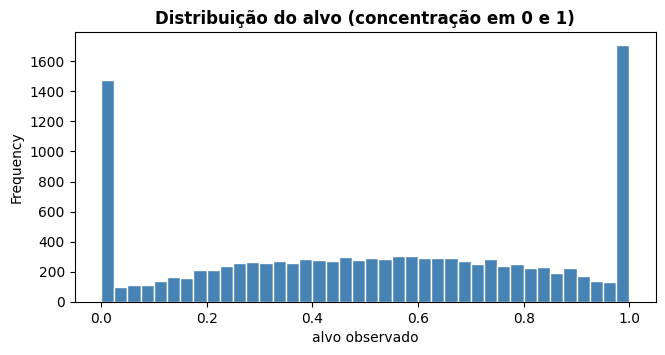

In [4]:
# A marca registrada deste alvo: distribuição bimodal com massa em 0 e 1.
fig_h, ax = plt.subplots(figsize=(7.5, 3.5))
df["target"].plot(kind="hist", bins=40, color="steelblue", edgecolor="white", ax=ax)
ax.set_title("Distribuição do alvo (concentração em 0 e 1)", fontweight="bold")
ax.set_xlabel("alvo observado")
plt.show()

## 2. `ColumnConfig`

Mesmo contrato de colunas do tutorial de classificação — muda apenas que o `target` é contínuo.

In [5]:
from yggdrasil import ColumnConfig
from yggdrasil.data import analysis_samples_present, scoring_only_samples_present

cfg = ColumnConfig()
print("Features:", cfg.feature_columns(df))
print("Amostras de análise:", analysis_samples_present(df, cfg))
print("Scoring-only       :", scoring_only_samples_present(df, cfg))

Features: ['feat_00', 'feat_01', 'feat_02', 'feat_03', 'feat_04', 'feat_05', 'feat_06']
Amostras de análise: ['DES', 'OOT']
Scoring-only       : ['SIMUL']


## 3. Treinar um modelo de regressão

Usamos um `RandomForestRegressor` treinado no DES. O **score** aqui é a própria previsão do alvo
(contínua), não uma probabilidade.

In [6]:
from sklearn.ensemble import RandomForestRegressor

feats = cfg.feature_columns(df)
treino = df[df["amostra"] == cfg.dev_sample]

model = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
model.fit(treino[feats], treino["target"])

df[cfg.score_col] = np.clip(model.predict(df[feats]), 0.0, 1.0)
dev = df[df["amostra"] == cfg.dev_sample]
oot = df[df["amostra"] == cfg.oot_sample]
df[["amostra", "target", cfg.score_col]].head()

,amostra,target,prediction
0,DES,0.7295,0.7175
1,OOT,0.5318,0.5450
2,DES,0.6104,0.5754
3,DES,0.7713,0.6877
4,DES,1.0000,0.8662


## 4. Métricas de regressão e *shifts*

Para regressão a esteira calcula **RMSE, MAE, MAPE (robusto), sMAPE, R², viés médio e MedAE**.
O MAPE é robusto: ignora alvos ≈ 0 (frequentes neste alvo) que estourariam a divisão.

In [7]:
from yggdrasil.metrics import metric_by_sample, sample_shifts

df_analise = df[df["amostra"].isin(cfg.analysis_samples)]
met = metric_by_sample(df_analise, cfg, "regression")
print("Métricas por amostra:")
display(pd.DataFrame(met).T)
print("Shifts DES -> OOT:")
display(pd.Series(sample_shifts(met, cfg), name="shift").to_frame())

Métricas por amostra:


,rmse,mae,mape,smape,medae,r2,mean_bias
DES,0.1078,0.0865,23.1920,39.3386,0.0733,0.8923,-0.0003
OOT,0.2932,0.2351,56.8062,58.9623,0.1980,0.2146,-0.0215


Shifts DES -> OOT:


,shift
rmse_shift_abs,0.1854
rmse_shift_rel,1.7196
mae_shift_abs,0.1486
mae_shift_rel,1.7179
mape_shift_abs,33.6143
mape_shift_rel,1.4494
smape_shift_abs,19.6237
smape_shift_rel,0.4988
medae_shift_abs,0.1247
medae_shift_rel,1.7012


## 5. Grupos homogêneos (ratings)

As mesmas 4 metodologias agrupam o **alvo previsto** em faixas ordenadas. A fusão monotônica
(quantil/árvore) usa o teste de **Mann-Whitney** no OOT (alvo contínuo).

In [8]:
from yggdrasil.ratings import build_ratings

rating_cols = []
for strat in build_ratings(["decis", "quantil", "arvore", "optbin"]):
    df[strat.column] = strat.fit_transform(df, cfg, "regression")
    rating_cols.append(strat.column)
    print(f"{strat.name:8s} -> {len(strat.labels_)} grupos: {strat.labels_}")

df_analise = df[df["amostra"].isin(cfg.analysis_samples)].copy()
print("Alvo médio observado por decil (DES):")
display(
    df[df["amostra"] == "DES"].groupby("rating_decis")["target"].mean().to_frame("alvo_medio")
)

decis    -> 10 grupos: ['R01', 'R02', 'R03', 'R04', 'R05', 'R06', 'R07', 'R08', 'R09', 'R10']
quantil  -> 18 grupos: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R']
arvore   -> 10 grupos: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']


optbin   -> 10 grupos: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
Alvo médio observado por decil (DES):


,alvo_medio
rating_decis,
R01,0.0202
R02,0.0951
R03,0.2438
R04,0.3654
R05,0.4737
R06,0.5697
R07,0.6692
R08,0.8103
R09,0.9216


## 6. PSI — estabilidade no tempo

In [9]:
from yggdrasil.monitoring import psi, psi_summary, psi_rating_over_time, classify_psi

p = psi(dev[cfg.score_col], oot[cfg.score_col])
print(f"PSI do alvo previsto (DES->OOT): {p:.4f}  [{classify_psi(p)}]")
print("PSI agregado:")
display(pd.Series(psi_summary(df_analise, cfg, rating_cols), name="psi").to_frame())
print("PSI do decil ao longo das safras:")
display(psi_rating_over_time(df, "rating_decis", cfg))

PSI do alvo previsto (DES->OOT): 0.5134  [instavel]
PSI agregado:


,psi
psi_score_oot,0.5134
psi_rating_decis_oot,0.5134
psi_rating_quantil_oot,0.6738
psi_rating_arvore_oot,0.4193
psi_rating_optbin_oot,0.5538


PSI do decil ao longo das safras:


,mes,psi,n,flag
0,2023-01-01,0.0017,966,estavel
1,2023-02-01,0.0037,1043,estavel
2,2023-03-01,0.0085,1010,estavel
3,2023-04-01,0.0061,1041,estavel
4,2023-05-01,0.0108,953,estavel
5,2023-06-01,0.0046,1020,estavel
6,2023-07-01,0.0091,1042,estavel
7,2023-08-01,0.0088,1000,estavel
8,2023-09-01,0.5137,974,instavel
9,2023-10-01,0.5144,1002,instavel


## 7. SHAP — interpretabilidade

In [10]:
from yggdrasil.interpretability import compute_shap, shap_feature_importance

shap_values, X_amostra = compute_shap(model, dev[feats], problem_type="regression",
                                      sample_size=1000)
display(shap_feature_importance(shap_values, feats))

,feature,mean_abs_shap
0,feat_06,0.0981
1,feat_00,0.0809
2,feat_05,0.0578
3,feat_04,0.0305
4,feat_01,0.0140
5,feat_03,0.0124
6,feat_02,0.0124


## 8. Relatório por grupo + dashboard

O `group_report` mostra o **alvo médio previsto vs observado** por grupo, representatividade e
monotonicidade. O dashboard inclui a seção SHAP (importância + beeswarm) ao passar `model` + `X_shap`.

In [11]:
from yggdrasil.reporting import group_report, is_monotonic

rep = group_report(df_analise, "rating_decis", cfg, "regression")
print("Monotônico?", is_monotonic(rep))
display(rep)

Monotônico? True


,rating,volume,pct_volume,score_medio,target_medio,score_min,score_max,vol_DES,pct_DES,target_medio_DES,score_medio_DES,vol_OOT,pct_OOT,target_medio_OOT,score_medio_OOT
0,R01,810,7.1053,0.1274,0.0305,0.0352,0.1731,769,10.0091,0.0202,0.1262,41,1.1030,0.2226,0.1492
1,R02,998,8.7544,0.2186,0.1346,0.1731,0.2612,768,9.9961,0.0951,0.2165,230,6.1878,0.2666,0.2259
2,R03,1261,11.0614,0.3086,0.2858,0.2613,0.3537,768,9.9961,0.2438,0.3067,493,13.2634,0.3511,0.3115
3,R04,1324,11.6140,0.3978,0.3928,0.3538,0.4404,768,9.9961,0.3654,0.3970,556,14.9583,0.4307,0.3988
4,R05,1324,11.6140,0.4811,0.4874,0.4404,0.5214,768,9.9961,0.4737,0.4813,556,14.9583,0.5064,0.4808
5,R06,1384,12.1404,0.5584,0.5721,0.5214,0.5984,769,10.0091,0.5697,0.5581,615,16.5456,0.5752,0.5587
6,R07,1322,11.5965,0.6402,0.6675,0.5985,0.6821,768,9.9961,0.6692,0.6394,554,14.9045,0.6652,0.6412
7,R08,1173,10.2895,0.7266,0.7766,0.6822,0.7693,768,9.9961,0.8103,0.7276,405,10.8959,0.7128,0.7247
8,R09,985,8.6404,0.8069,0.8926,0.7696,0.8445,768,9.9961,0.9216,0.8079,217,5.8380,0.7898,0.8030
9,R10,819,7.1842,0.8856,0.9746,0.8446,0.9719,769,10.0091,0.9815,0.8872,50,1.3452,0.8684,0.8610


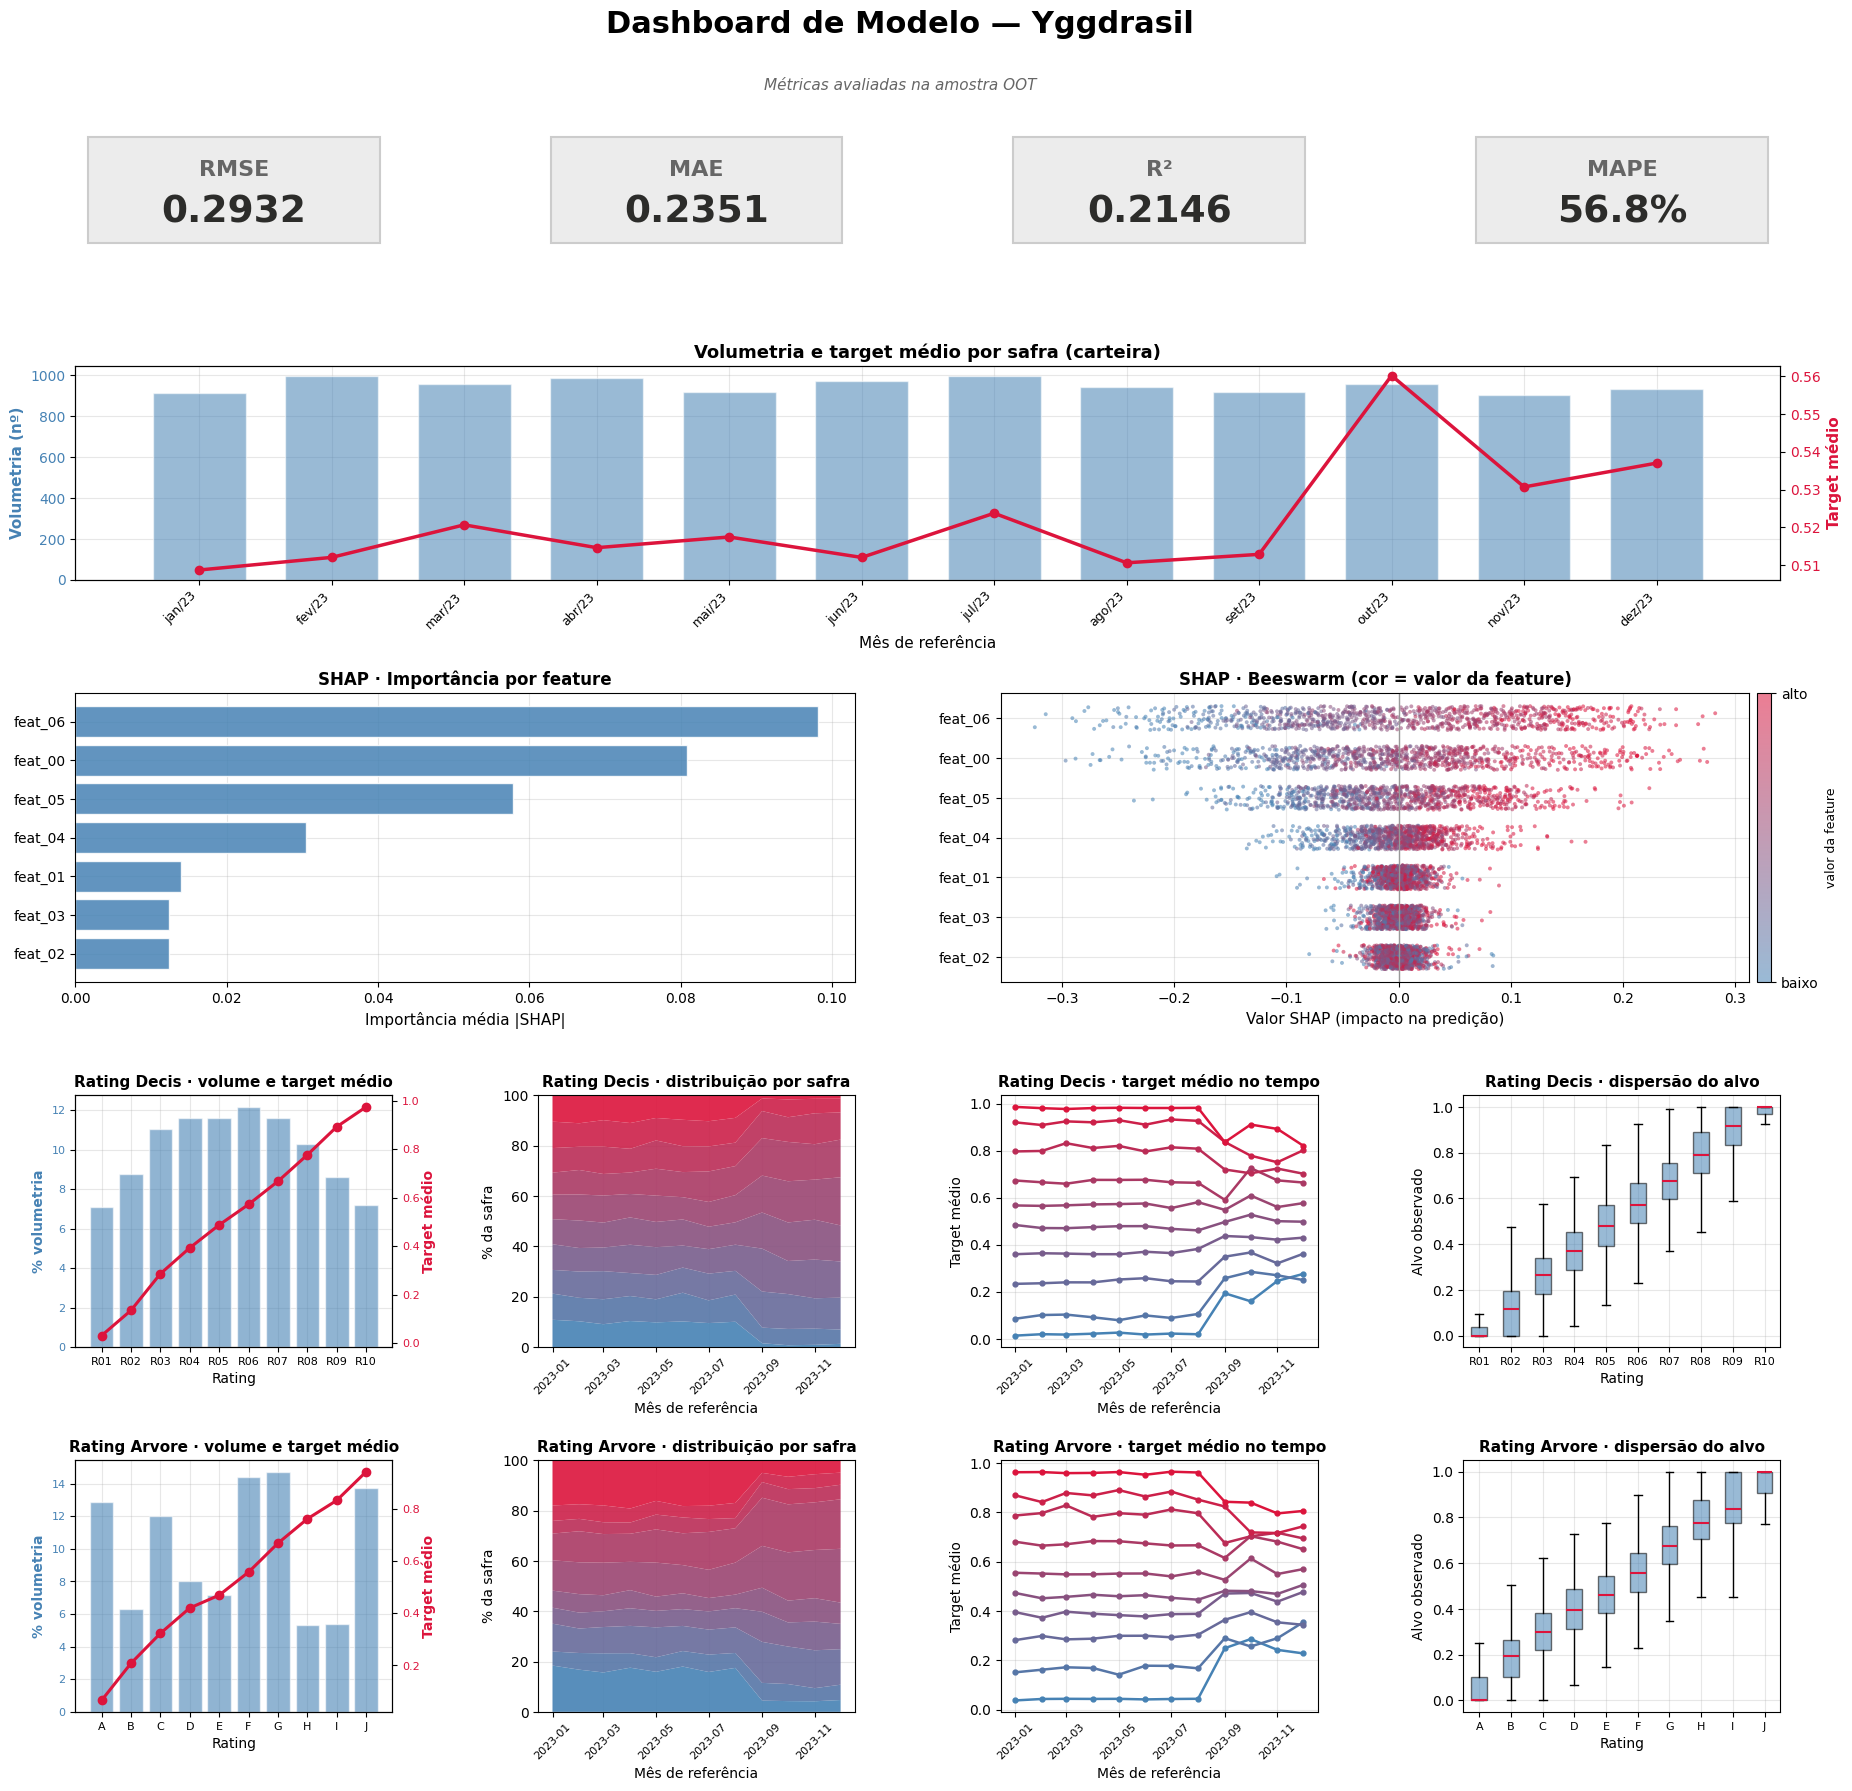

In [12]:
from yggdrasil.reporting import build_dashboard

fig = build_dashboard(df_analise, ["rating_decis", "rating_arvore"], cfg,
                      "regression", metrics=met.get("OOT", {}),
                      model=model, X_shap=dev[feats])
fig

## 9. Esteira completa com MLflow

In [13]:
import mlflow
from yggdrasil import MLPipeline

mlflow.set_tracking_uri("file:./mlruns")
pipe = MLPipeline(cfg, problem_type="regression",
                  ratings=["decis", "quantil", "arvore", "optbin"])
resultado = pipe.run(df, model=model, experiment="tutorial_regressao",
                     run_name="regressao", tags={"model_type": "regressao"})
print("run_id:", resultado.run_id)
display(pd.DataFrame(resultado.metrics_by_sample).T)

2026/07/12 17:43:09 INFO mlflow.tracking.fluent: Experiment with name 'tutorial_regressao' does not exist. Creating a new experiment.


2026/07/12 17:49:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/07/12 17:49:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


run_id: 311c37b9e4b14508a69a0664d0e75ba4


,rmse,mae,mape,smape,medae,r2,mean_bias
DES,0.1078,0.0865,23.1920,39.3386,0.0733,0.8923,-0.0003
OOT,0.2932,0.2351,56.8062,58.9623,0.1980,0.2146,-0.0215


## 10. Amostras *scoring-only* e MLflow

Como na classificação, amostras fora de `analysis_samples` (ex.: `SIMUL`) recebem o alvo previsto + rating, mas
ficam fora da análise. Veja os runs com `mlflow ui --backend-store-uri ./mlruns`.

In [14]:
print("Amostras com análise:", list(resultado.metrics_by_sample.keys()))
display(
    resultado.df_scored[resultado.df_scored["amostra"] == "SIMUL"]
    [["amostra", cfg.score_col] + resultado.rating_cols].head()
)

Amostras com análise: ['DES', 'OOT']


,amostra,prediction,rating_decis,rating_quantil,rating_arvore,rating_optbin
17,SIMUL,0.5883,R06,J,G,F
22,SIMUL,0.3761,R04,F,C,F
35,SIMUL,0.6973,R08,M,H,F
58,SIMUL,0.4405,R05,G,D,F
128,SIMUL,0.5786,R06,J,F,F
